In [54]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from rembg import remove
from PIL import Image
import io


In [55]:
path = "/mnt/disk3/namnp/DeYO/DATA/Waterbirds/189.Red_bellied_Woodpecker/Red_Bellied_Woodpecker_0023_181958.jpg"
# path = "/mnt/disk3/namnp/DeYO/DATA/Waterbirds/154.Red_eyed_Vireo/Red_Eyed_Vireo_0019_156921.jpg"
# path = "./DATA/Waterbirds/001.Black_footed_Albatross/Black_Footed_Albatross_0006_796065.jpg"
# path = "./DATA/Waterbirds/123.Henslow_Sparrow/Henslow_Sparrow_0009_796611.jpg"

output_path = "./DATA_FG"
# path = "./DATA/cifar10_c/brightness/5/0/040011.jpg"

*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/python/onnxruntime_pybind_state.cc:490 void onnxruntime::python::RegisterTensorRTPluginsAsCustomOps(PySessionOptions&, const onnxruntime::ProviderOptions&) Please install TensorRT libraries as mentioned in the GPU requirements page, make sure they're in the PATH or LD_LIBRARY_PATH, and that your GPU is supported.
 when using ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Falling back to ['CUDAExecutionProvider', 'CPUExecutionProvider'] and retrying.
****************************************


2024-12-09 05:38:36.579201916 [E:onnxruntime:Default, provider_bridge_ort.cc:1978 TryGetProviderInfo_TensorRT] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1637 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_tensorrt.so with error: libcudnn.so.9: cannot open shared object file: No such file or directory

2024-12-09 05:38:36.688608476 [E:onnxruntime:Default, provider_bridge_ort.cc:1992 TryGetProviderInfo_CUDA] /onnxruntime_src/onnxruntime/core/session/provider_bridge_ort.cc:1637 onnxruntime::Provider& onnxruntime::ProviderLibrary::Get() [ONNXRuntimeError] : 1 : FAIL : Failed to load library libonnxruntime_providers_cuda.so with error: libcublasLt.so.12: cannot open shared object file: No such file or directory



(375, 500, 4)


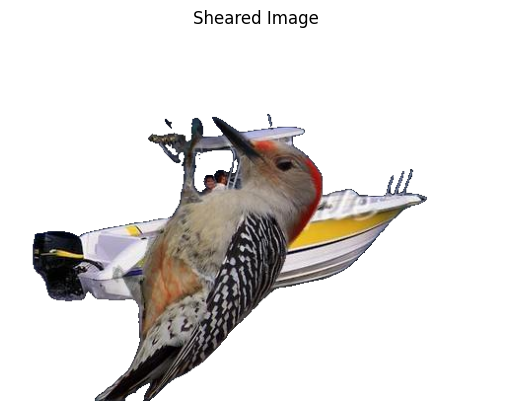

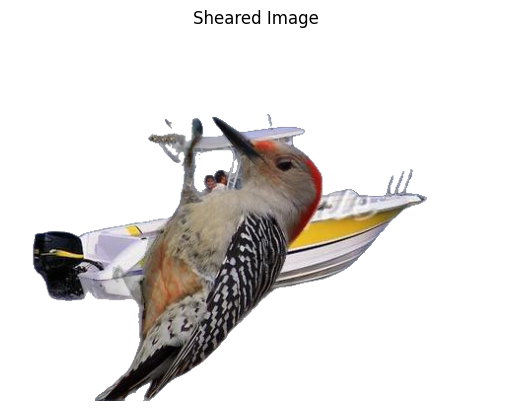

In [ ]:
with open(path, 'rb') as input_file:
    input_data = input_file.read()
    output_data = remove(input_data)

# # Save the result
# with open(output_path, 'wb') as output_file:
#     output_file.write(output_data)

# # Alternatively, if you want to display the image using PIL:
# image = Image.open(io.BytesIO(output_data))

image = Image.open(io.BytesIO(output_data))

image_np = np.array(image)
print(image_np.shape)
rgb, alpha = image_np[:, :, :3], image_np[:, :, 3]
background_mask = alpha < 100
rgb[background_mask] = [255, 255, 255] 
# image_np = image_np[:, :, :3]
plt.imshow(rgb)
plt.title("Sheared Image")
plt.axis("off")
plt.show()
plt.imshow(image_np)
plt.title("Sheared Image")
plt.axis("off")
plt.show()

(375, 500, 3)


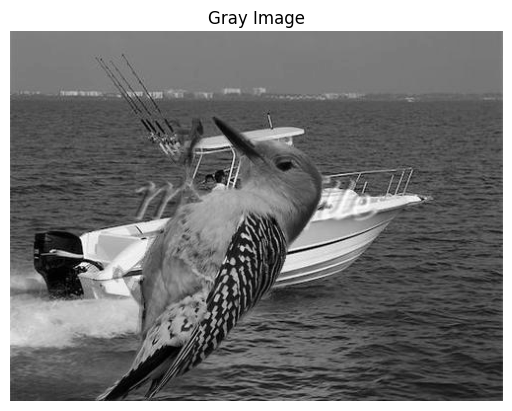

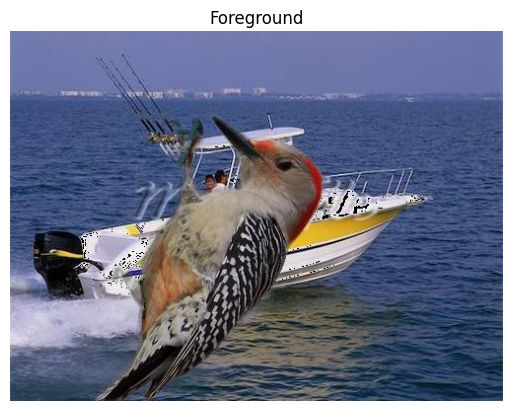

In [57]:

image = cv2.imread(path)
print(image.shape)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')  
plt.title("Gray Image")
plt.axis("off")  
plt.show()
_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)

mask_inv = cv2.bitwise_not(mask)

fg = cv2.bitwise_and(image, image, mask = mask_inv)

plt.imshow(fg)
plt.title("Foreground")
plt.axis("off")  
plt.show()
# cv2.waitKey(0)
# cv2.destroyAllWindows()